In [1]:
library(here)
library("misha")
library("misha.ext")
library("zoo")
library("tglkmeans")
library("misha.ext")
library(tidyverse)
library(tgstat)
library(prego)
library(tgutil)
#gdb.reload()
options(gmax.data.size = 1e10)
options(gmultitasking = FALSE)


link_dir = link_dir =  paste0(here(),'/')
setwd(here())

gsetroot(paste0(link_dir,'data/mm10/'))

gdb.reload()

source(paste0(link_dir,'code/seq2epi_utils.r'))
source(paste0(link_dir,'code/fig_fun.r'))



mod = init_pipe()
mod$epi_tss = mod$tss

here() starts at /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_raw


Attaching package: ‘misha.ext’


The following objects are masked from ‘package:misha’:

    gintervals.mark_overlaps, gintervals.normalize



Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘xgboost’


The following object is masked from ‘package:dplyr’:

    slice




In [2]:
compute_crop_bp <- function(seq_len = 65536, bin_size_bp = 32, prediction_fraction = 0.5) {
  # total number of bins Borzoi outputs
  total_bins <- seq_len / bin_size_bp
  
  # number of bins we keep in the center
  pred_bins  <- total_bins * prediction_fraction
  
  # bins to trim each side
  crop_left_bins  <- floor((total_bins - pred_bins) / 2)
  crop_right_bins <- (total_bins - pred_bins) - crop_left_bins
  
  # convert to base pairs
  crop_left_bp  <- crop_left_bins  * bin_size_bp
  crop_right_bp <- crop_right_bins * bin_size_bp
  
  list(
    total_bp      = seq_len,
    total_bins    = as.integer(total_bins),
    kept_bins     = as.integer(pred_bins),
    kept_bp       = as.integer(pred_bins * bin_size_bp),
    crop_left_bp  = as.integer(crop_left_bp),
    crop_right_bp = as.integer(crop_right_bp)
  )
}
compute_crop_bp()

$total_bp
[1] 65536

$total_bins
[1] 2048

$kept_bins
[1] 1024

$kept_bp
[1] 32768

$crop_left_bp
[1] 16384

$crop_right_bp
[1] 16384

In [3]:

align_to_bin_size <- function(regions, bin_size = 32) {
    regions %>%
        mutate(
            start = floor(start / bin_size) * bin_size,
            end = floor(end / bin_size) * bin_size
        )
}

perpare_regions <- function(regions, seq_len = 65536, bin_size = 32) {
    crops <- compute_crop_bp(seq_len, bin_size)
    cli::cli_alert("Kept: {.val {crops$kept_bp}}, total: {.val {crops$total_bp}}, crop_left: {.val {crops$crop_left_bp}}, crop_right: {.val {crops$crop_right_bp}}")
    cli::cli_alert_info("initial number of regions: {.val {nrow(regions)}}")
    
    regions <- regions %>% gintervals.normalize(seq_len) 
    new_regions <- NULL

    while(is.null(new_regions) || nrow(regions) != nrow(new_regions)) {
        if (!is.null(new_regions)) {
            regions <- new_regions
        }
        new_regions <- regions %>% 
            gintervals.normalize(seq_len) %>%
            gintervals.canonic()        
        cli::cli_alert_info("New number of regions: {.val {nrow(new_regions)}}")
    }
    regions <- regions %>% 
        gintervals.normalize(seq_len) 
    regions <- align_to_bin_size(regions, bin_size)      
    stopifnot(all((regions$start %% 32) == 0))
    stopifnot(all((regions$end %% 32) == 0))
    
    return(regions)
}

set.seed(60427)
random_regs <- gintervals.random(size = 2e3, n = 5e3, filter = mod$cgdom_ann)
initial_regs <- bind_rows(mod$cgdom_ann %>% select(chrom, start, end), random_regs)
regs <- perpare_regions(initial_regs) 
cli::cli_alert_info("Covered: {.val {scales::comma(gintervals.covered_bp(regs))}bp}")
dir.create(here("output/data-for-borzoi"), showWarnings = FALSE)
fwrite(regs, here("output/data-for-borzoi/borzoi_regions.bed"), sep = "\t", col.names = FALSE, quote = FALSE, scipen = 9999)

→ Kept: 32768, total: 65536, crop_left: 16384, crop_right: 16384

ℹ initial number of regions: 24448

ℹ New number of regions: 9450

ℹ New number of regions: 9450

ℹ Covered: "619,315,200bp"



,chrom,start,end,l
,<fct>,<dbl>,<dbl>,<dbl>
1,chr1,3355904,3421440,65536
2,chr1,3493600,3559136,65536
3,chr1,3638784,3704320,65536
4,chr1,3755712,3821248,65536
5,chr1,3996544,4062080,65536
6,chr1,4271296,4336832,65536


0%    5%   10%   15%   20%   25%   30%   35%   40%   45%   50%   55%   60% 
65536 65536 65536 65536 65536 65536 65536 65536 65536 65536 65536 65536 65536 
  65%   70%   75%   80%   85%   90%   95%  100% 
65536 65536 65536 65536 65536 65536 65536 65536

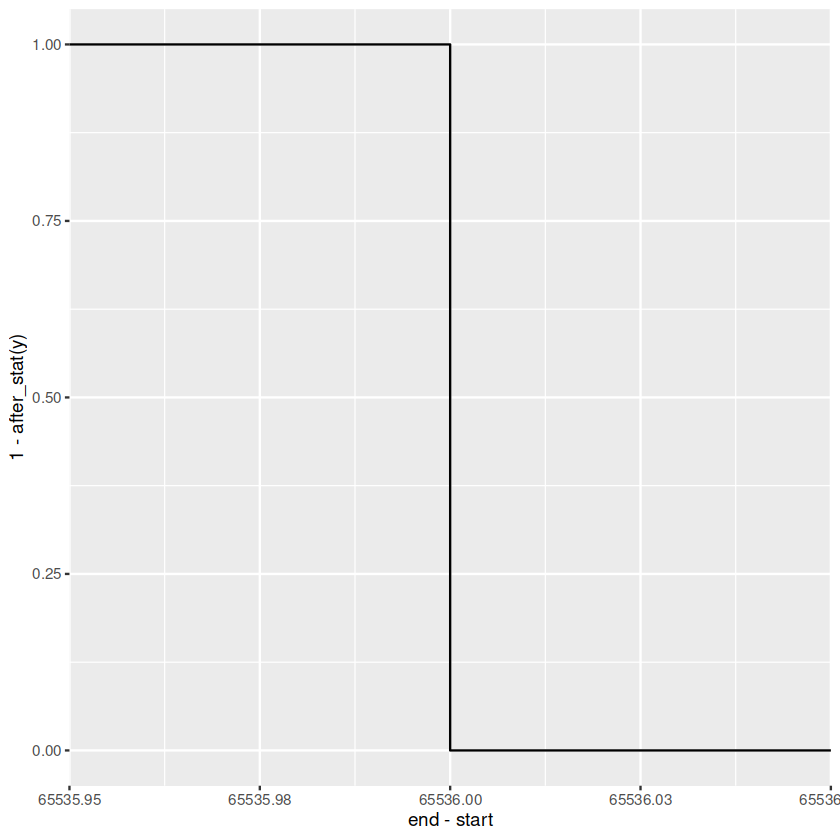

In [4]:
sps(7, 7)
regs %>% mutate(l = end - start) %>% arrange(l) %>% head
quantile(regs$end - regs$start, 0:20/20)
regs %>% 
    ggplot(aes(x = end - start, y = 1-after_stat(y))) + stat_ecdf() 

In [ ]:
gen_k27_vt(mod)
gen_k4_vt(mod)
gvtrack.create("e65_epi_atac", "mut_multi.WT_E65.epi", func = "sum")
gvtrack.iterator("e65_epi_atac", sshift = -140, eshift = 140)
gvtrack.create("e70_epi_atac", "mut_multi.WT_E70.epi", func = "sum")
gvtrack.iterator("e70_epi_atac", sshift = -140, eshift = 140)
gvtrack.create("e75_epi_atac", "mut_multi.WT_E75.epi", func = "sum")
gvtrack.iterator("e75_epi_atac", sshift = -140, eshift = 140)
borzoi_vt <- c('ES_cnt','ES2i_cnt','EB4_cnt','e75_ecto_cnt','e75_emeso_cnt', "EB4_cnt_k4", "e65_epi_atac", "e70_epi_atac", "e75_epi_atac")
borzoi_data <- gextract.left_join(borzoi_vt, intervals = regs, iterator = 32) %>% 
    mutate_at(borzoi_vt, ~ ifelse(is.na(.), 0, .)) %>%
    group_by(chrom) %>%     
    mutate_at(borzoi_vt, ~ iceqream::norm01(log2(1 + .))) %>%     
    ungroup() %>% 
    mutate(region = paste0(chrom1, ":", start1, "-", end1)) %>% 
    select(-chrom1, -start1, -end1) %>% 
    select(chrom, start, end, region, everything()) %>% 
    arrange(chrom, start) %fcache_df% here("output/data-for-borzoi/borzoi_data.tsv")

[1] "ES_ch_k4"           "EB4_cnt_k4"         "e105_foreb_k4"     
[4] "e105_face_k4"       "e105_limb_k4"       "e135_neur_tube_k4" 
[7] "e145_intenstine_k4" "e155_kidney_k4"     "e155_lung_k4"

In [6]:
arrow::write_parquet(borzoi_data, here("output/data-for-borzoi/borzoi_data.parquet"), compression = "snappy")

In [ ]:
borzoi_data_no_norm <- gextract.left_join(borzoi_vt, intervals = regs, iterator = 32) %>% 
    mutate_at(borzoi_vt, ~ ifelse(is.na(.), 0, .)) %>%
    group_by(chrom) %>%     
    # mutate_at(borzoi_vt, ~ log2(1 + .)) %>%     
    ungroup() %>% 
    mutate(region = paste0(chrom1, ":", start1, "-", end1)) %>% 
    select(-chrom1, -start1, -end1) %>% 
    select(chrom, start, end, region, everything()) %>% 
    arrange(chrom, start) %fcache_df% here("output/data-for-borzoi/borzoi_data_no_norm.tsv")
arrow::write_parquet(borzoi_data_no_norm, here("output/data-for-borzoi/borzoi_data_no_norm.parquet"), compression = "snappy")

In [7]:
borzoi_data %>% count(region) %>% count(n, name = "num_of_regs")

n,num_of_regs
<int>,<int>
2048,9450


In [ ]:
browser()

In [ ]:
regs_500k <- perpare_regions(initial_regs, 524288)
cli::cli_alert_info("Covered: {.val {scales::comma(gintervals.covered_bp(regs_500k))}bp}")
dir.create(here("output/data-for-borzoi"), showWarnings = FALSE)
fwrite(regs_500k, here("output/data-for-borzoi/borzoi_regions_500k.bed"), sep = "\t", col.names = FALSE, quote = FALSE, scipen = 9999)

In [ ]:
gen_k27_vt(mod)
gen_k4_vt(mod)
gvtrack.create("e65_epi_atac", "mut_multi.WT_E65.epi", func = "sum")
gvtrack.iterator("e65_epi_atac", sshift = -140, eshift = 140)
gvtrack.create("e70_epi_atac", "mut_multi.WT_E70.epi", func = "sum")
gvtrack.iterator("e70_epi_atac", sshift = -140, eshift = 140)
gvtrack.create("e75_epi_atac", "mut_multi.WT_E75.epi", func = "sum")
gvtrack.iterator("e75_epi_atac", sshift = -140, eshift = 140)
borzoi_vt <- c('ES_cnt','ES2i_cnt','EB4_cnt','e75_ecto_cnt','e75_emeso_cnt', "EB4_cnt_k4", "e65_epi_atac", "e70_epi_atac", "e75_epi_atac")
borzoi_data_no_norm <- gextract.left_join(borzoi_vt, intervals = regs_500k, iterator = 32) %>% 
    mutate_at(borzoi_vt, ~ ifelse(is.na(.), 0, .)) %>%
    group_by(chrom) %>%     
    # mutate_at(borzoi_vt, ~ log2(1 + .)) %>%     
    ungroup() %>% 
    mutate(region = paste0(chrom1, ":", start1, "-", end1)) %>% 
    select(-chrom1, -start1, -end1) %>% 
    select(chrom, start, end, region, everything()) %>% 
    arrange(chrom, start) %fcache_df% here("output/data-for-borzoi/borzoi_data_no_norm_500k.tsv")
arrow::write_parquet(borzoi_data_no_norm, here("output/data-for-borzoi/borzoi_data_no_norm_500k.parquet"), compression = "snappy")

In [ ]:
gdir.create("borzoi", showWarnings = FALSE)
gtrack.import(file = "/home/aviezerl/proj/ebpcg/seq2epi_paper_raw/output/predictions/64kb_cosine_mse_log/EB4_cnt.bw", track = "borzoi.finetune_64k_EB4_cnt", description = "", binsize = 20)

In [ ]:
plt_genome_pred_ppt_borzoi = function(mod, g = NA, off5 = NA, off3 = NA,mark_reg=NA,
                                      chrom = NULL, locus = NULL, win_smooth = 1, show_center=T,
                                      plot_pred_doms = F,
                                      label_tss = F,
                                      pred_lwd=1, plot_base_pred = F,
                                      fn=NULL, fn_w = 15, fn_h=10, 
                                      more_tracks=c(), log_tracks=c())
{
  if(!is.null(fn)) {
      if(grepl("pdf", fn)) {
            pdf(fn, w=fn_w, h=fn_h)
      } else {
            png(fn, w=fn_w, h=fn_h)
      }
  }
  cg_trace = mod$gw$cg_trace
  if(is.null(chrom)) {
    f = mod$tss$geneSymbol==g
    if(sum(f) == 0) {
      return
    }
    hits = mod$tss[f,]
    locus = mean(mod$tss$start[f])
    chrom = hits[1,"chrom"]
  }
  f = as.character(cg_trace$chrom) == chrom & (cg_trace$start > locus + off5 & cg_trace$start < locus + off3)
  
  tss = mod$epi_tss[mod$epi_tss$chrom == chrom & (mod$epi_tss$start > locus + off5 & mod$epi_tss$start < locus + off3),]
  
  add_n = length(more_tracks)
  #layout(matrix(1:(2+add_n), ncol=1),h=c(rep(1, 3+add_n),1.3))
  layout(matrix(1:(2+add_n), ncol=1), heights=c(1.1, .95, rep(1, add_n))) # Adjusted heights to accommodate n tracks
  
  par(mar = c(0, 3, 2, 3))
  maxy = max(max(cg_trace$lk27_1k[f]),7)
  pred_sm = zoo::rollmean(cg_trace$pred[f], win_smooth, f='e')
  pred_segs = which(pred_sm[-1]>4 & pred_sm[-length(pred_sm)] < 4)
  pred_segs = c(pred_segs, which(pred_sm[-1]<4 & pred_sm[-length(pred_sm)] > 4))
  pred_segs_xs = cg_trace$start[f][pred_segs]
  obs = cg_trace$lk27_1k[f]
  r2 = cor(pmax(obs,2), pmax(pred_sm,2))**2
  obs_given_pred = round(sum(obs > 4 & pred_sm > 4)/(1+sum(pred_sm > 4)),3)
  pred_given_obs = round(sum(obs > 4 & pred_sm > 4)/(1+sum(obs > 4)),3)
  
  plot(cg_trace$start[f], cg_trace$lk27_1k[f],
       t="l", ylim=c(1,maxy), lwd=1,col="blue",
       xaxt='n',
       main=sprintf("EB4 locus r2 = %s, obs|pred %s, pred|obs %s",
                    round(r2,3), obs_given_pred, pred_given_obs),
       xlab=sprintf("chr %s, %s", cg_trace$chrom[f][1], g))
  polygon(c(cg_trace$start[f], rev(cg_trace$start[f])), c(cg_trace$lk27_1k[f], rep(1, length(cg_trace$lk27_1k[f]))),
          col="blue", border=NA)
  #if(nrow(tss) > 0) {
  #     points(tss$start, pmin(1.5+tss$epi_rna-log2(1e-5),7.5), pch=19, col="red",cex=1.5)
  #}
  abline(h=log2(19), lty=2)
  if(plot_pred_doms) {
    segments(x0 = pred_segs_xs, x1=pred_segs_xs,
             y0 = rep(0,length(pred_segs_xs)),
             y1 = rep(maxy,length(pred_segs_xs)), lty=1)
  }
  
  if(show_center) {
    abline(v=locus, col="black", lwd=1)
  }
  if(!is.na(mark_reg[1])) {
    for (mark in 1:length(mark_reg)){
      abline(v=mark_reg[mark], col="black", lwd=1)}
  }
  par(mar = c(0, 3, 1, 3))
  #par(mar = c(2,3,1, 3))
  plot(cg_trace$start[f], pred_sm, t="l", col="darkblue",xaxt='n', ylim=c(1,maxy), xlab=cg_trace$chrom[f][1],
       lwd=pred_lwd, main="prediction")
  polygon(c(cg_trace$start[f], rev(cg_trace$start[f])), c(pred_sm, rep(1, length(pred_sm))),
          col="darkblue", border=NA)
  if(!is.na(mark_reg[1])) {
    for (mark in 1:length(mark_reg)){
      abline(v=mark_reg[mark], col="black", lwd=1)}
  }
  if(plot_base_pred) {
    pred_sm_b = zoo::rollmean(cg_trace$pred_base[f], win_smooth, f='e')
    lines(cg_trace$start[f], pred_sm_b, t="l", col="cyan", ylim=c(1,maxy), lwd=pred_lwd, xlab=cg_trace$chrom[f][1])
  }
  if(label_tss) {
    if(nrow(tss) > 0) {
      par(srt=-45)
      text(x = tss$start, y = rep(maxy-2,t=nrow(tss)), labels=tss$geneSymbol, cex=1.5)
    }
  }
  
  if(plot_pred_doms) {
    segments(x0 = pred_segs_xs, x1=pred_segs_xs,
             y0 = rep(0,length(pred_segs_xs)),
             y1 = rep(maxy,length(pred_segs_xs)), lty=1)
  }
  abline(h=log2(19), lty=2)
  if(show_center) {
    abline(v=locus, col="black",lwd=2)
  }
  

  if(length(more_tracks) != 0) {
    profs = gextract(more_tracks, intervals=cg_trace[f,1:3], iterator=cg_trace[f,1:3])
    profs[is.na(profs)] = 0
    for(i in 1:length(more_tracks)) {
      par(mar = c(4, 3, 1, 3))
      
      # 1. Smooth (5 bins of 200bp, consistent with upper plots)
      sm_prf = zoo::rollmean(profs[,more_tracks[i]], 5, f='e')
      
      # 2. Log if requested (after smoothing)
      if (more_tracks[i] %in% log_tracks) {
         # Using log2(x+1) to handle zeros and match common genomics scalings
         sm_prf = log2(sm_prf + 1)
         track_label = sprintf("%s (log2)", more_tracks[i])
      } else {
         track_label = more_tracks[i]
      }
      
      obs = cg_trace$lk27_1k[f]
      r2 = cor(obs, sm_prf)**2
      obs_given_pred = round(sum(obs > 4 & sm_prf > 0.1)/(1+sum(sm_prf > 0.1)),3)
      pred_given_obs = round(sum(obs > 4 & sm_prf > 0.1)/(1+sum(obs > 4)),3)
      
      # 3. Dynamic Y-max
      track_max = max(sm_prf, na.rm=TRUE)
      if(track_max == 0) track_max = 1 
      
      plot(cg_trace$start[f], (sm_prf), t="l", col="darkgreen", 
           ylim=c(0, track_max), 
           lwd=pred_lwd,
           main=sprintf("%s borzoi locus r2 = %s, obs|pred %s, pred|obs %s",
                        track_label, round(r2,3), obs_given_pred, pred_given_obs),)
      polygon(
        c(cg_trace$start[f], rev(cg_trace$start[f])),
        c(sm_prf, rep(0, length(sm_prf))),
        col="darkgreen", border=NA
      )
    }
  }
  # -----------------------------------------
  
  if(!is.null(fn)) {
    dev.off()
  }
}

In [ ]:
mod = readRDS("data/cache_mod.RDS")
mod$gw$cg_trace = readRDS('data/cg_trace_mm10.rds')


In [ ]:
plot_borzoi_debug_loci <- function(
  mod, 
  dir, 
  more_tracks, 
  log_tracks
) {
  dir.create(dir, showWarnings = FALSE, recursive = TRUE)
  
  plot_list <- list(
    list(chrom = "chr14", locus = 46390668, horiz = 1e5, fn = file.path(dir, "GW_hoxa.pdf")),
    list(chrom = "chr3", locus = 34650614, horiz = .5e5, fn = file.path(dir, "GW_hoxd_locus1.pdf")),
    list(chrom = "chr3", locus = 87950753, horiz = .5e5, fn = file.path(dir, "GW_hoxd_locus2.pdf")),
    list(chrom = "chr2", locus = 74683351, horiz = 1.5e5, fn = file.path(dir, "GW_chr2_locus.pdf")),
    list(chrom = "chr15", locus = 102990409, horiz = 4.5e5, fn = file.path(dir, "GW_hoxa_chr15.pdf")),
    list(chrom = "chr11", locus = 96284150, horiz = 2e5, fn = file.path(dir, "GW_hoxb.pdf")),
    list(chrom = "chr6", locus = 52233936, horiz = 1e5, fn = file.path(dir, "GW_hoxa_chr6.pdf"))
  )
  
  for (plt in plot_list) {
    plt_genome_pred_ppt_borzoi(
      mod,
      g = NA,
      off5 = -plt$horiz,
      off3 = plt$horiz,
      chrom = as.character(plt$chrom),
      locus = plt$locus,
      label_tss = FALSE,
      fn_w = 15,
      fn_h = 10,
      fn = here(plt$fn),
      more_tracks = more_tracks,
      log_tracks = log_tracks
    )
  }
}


pred_track <- "borzoi.finetune_64k_EB4_cnt"
plot_borzoi_debug_loci(
  mod = mod, 
  dir = here("figs/borzoi-debug"), 
  more_tracks = c(pred_track, 'jk.epipcg.pred.EB4_cnt_smooth'),
  log_tracks = c(pred_track)
)

plot_borzoi_debug_loci(
  mod = mod, 
  dir = here("figs/borzoi-debug-noatac"), 
  more_tracks = c("borzoi.finetune_64k_EB4_cnt_no_atac", 'borzoi.finetune_64k_EB4_cnt'),
  log_tracks = c("borzoi.finetune_64k_EB4_cnt_no_atac", 'borzoi.finetune_64k_EB4_cnt')
)


ERROR: Error in here("figs/borzoi-debug"): could not find function "here"


In [ ]:
gdir.create("borzoi", showWarnings = FALSE)
gtrack.import(file = "/home/aviezerl/proj/ebpcg/seq2epi_paper_raw/output/predictions/64kb_cosine_mse_log_all_genome/EB4_cnt.bw", track = "borzoi.finetune_64k_EB4_cnt_no_atac", description = "", binsize = 20)

In [ ]:

pred_track <- "borzoi.finetune_64k_EB4_cnt_no_atac"
dir <- here("figs/borzoi-debug-noatac")
dir.create(dir, showWarnings = FALSE)

# chr14 - HOXA region, reference plot (already in debug format)
horiz = 1e5
plt_genome_pred_ppt_borzoi(
    mod,
    g = NA,
    off5 = -horiz, off3 = horiz,
    chrom = as.character('chr14'), locus = 46390668,
    label_tss = F,
    fn_w = 15,
    fn_h = 10,
    fn = here(glue("{dir}/GW_hoxa.pdf")),
    more_tracks = c(pred_track, 'jk.epipcg.pred.EB4_cnt_smooth'),
    log_tracks = c(pred_track)
)

# chr3 - HOXD 1
horiz = .5e5
plt_genome_pred_ppt_borzoi(
    mod,
    g = NA,
    off5 = -horiz, off3 = horiz,
    chrom = as.character('chr3'), locus = 34650614,
    label_tss = F,
    fn_w = 15,
    fn_h = 10,
    fn = here(glue("{dir}/GW_hoxd_locus1.pdf")),
    more_tracks = c(pred_track, 'jk.epipcg.pred.EB4_cnt_smooth'),
    log_tracks = c(pred_track)
)

# chr3 - HOXD 2
horiz = .5e5
plt_genome_pred_ppt_borzoi(
    mod,
    g = NA,
    off5 = -horiz, off3 = horiz,
    chrom = as.character('chr3'), locus = 87950753,
    label_tss = F,
    fn_w = 15,
    fn_h = 10,
    fn = here(glue("{dir}/GW_hoxd_locus2.pdf")),
    more_tracks = c(pred_track, 'jk.epipcg.pred.EB4_cnt_smooth'),
    log_tracks = c(pred_track)
)

# chr2 region
horiz = 1.5e5
plt_genome_pred_ppt_borzoi(
    mod,
    g = NA,
    off5 = -horiz, off3 = horiz,
    chrom = as.character('chr2'), locus = 74683351,
    label_tss = F,
    fn_w = 15,
    fn_h = 10,
    fn = here(glue("{dir}/GW_chr2_locus.pdf")),
    more_tracks = c(pred_track, 'jk.epipcg.pred.EB4_cnt_smooth'),
    log_tracks = c(pred_track)
)

# chr15 - HOXA region
horiz = 4.5e5
plt_genome_pred_ppt_borzoi(
    mod,
    g = NA,
    off5 = -horiz, off3 = horiz,
    chrom = as.character('chr15'), locus = 102990409,
    label_tss = F,
    fn_w = 15,
    fn_h = 10,
    fn = here(glue("{dir}/GW_hoxa_chr15.pdf")),
    more_tracks = c(pred_track, 'jk.epipcg.pred.EB4_cnt_smooth'),
    log_tracks = c(pred_track)
)

# chr11 - HOXB region
horiz = 2e5
plt_genome_pred_ppt_borzoi(
    mod,
    g = NA,
    off5 = -horiz, off3 = horiz,
    chrom = as.character('chr11'), locus = 96284150,
    label_tss = F,
    fn_w = 15,
    fn_h = 10,
    fn = here(glue("{dir}/GW_hoxb.pdf")),
    more_tracks = c(pred_track, 'jk.epipcg.pred.EB4_cnt_smooth'),
    log_tracks = c(pred_track)
)

# chr6 - HOXA region
horiz = 1e5
plt_genome_pred_ppt_borzoi(
    mod,
    g = NA,
    off5 = -horiz, off3 = horiz,
    chrom = as.character('chr6'), locus = 52233936,
    label_tss = F,
    fn_w = 15,
    fn_h = 10,
    fn = here("figs/borzoi-debug/GW_hoxa_chr6.pdf"),
    more_tracks = c(pred_track, 'jk.epipcg.pred.EB4_cnt_smooth'),
    log_tracks = c(pred_track)
)


In [ ]:
pred_eb4_cnt <- rtracklayer::import("/home/aviezerl/proj/ebpcg/seq2epi_paper_raw/output/data-for-borzoi/predictions/64kb_context_pytroch/EB4_cnt.bw") %>% 
    as.data.frame() %>% 
    rename(chrom = seqnames) %>% 
    mutate(start = start - 1, end = end) %>% 
    select(-strand)

In [ ]:
val_chroms <- c("chr8", "chr10")
test_chroms <- c("chr9", "chr18")
a <- pred_eb4_cnt %>% left_join(borzoi_data) %>% filter(!is.na(EB4_cnt)) %>% mutate(type = case_when(chrom %in% val_chroms ~ "val", chrom %in% test_chroms ~ "test", TRUE ~ "train"))

In [ ]:
a %>% group_by(type) %>% summarise(r2 = cor(EB4_cnt, score)^2)

In [ ]:
gen_k27_vt(mod)
gen_k4_vt(mod)
gvtrack.create("e65_epi_atac", "mut_multi.WT_E65.epi", func = "sum")
gvtrack.iterator("e65_epi_atac", sshift = -140, eshift = 140)
gvtrack.create("e70_epi_atac", "mut_multi.WT_E70.epi", func = "sum")
gvtrack.iterator("e70_epi_atac", sshift = -140, eshift = 140)
gvtrack.create("e75_epi_atac", "mut_multi.WT_E75.epi", func = "sum")
gvtrack.iterator("e75_epi_atac", sshift = -140, eshift = 140)
borzoi_vt <- c('ES_cnt','ES2i_cnt','EB4_cnt','e75_ecto_cnt','e75_emeso_cnt', "EB4_cnt_k4", "e65_epi_atac", "e70_epi_atac", "e75_epi_atac")
full_data <- gextract(borzoi_vt, intervals = gintervals.all(), iterator = 32) %>% 
    mutate_at(borzoi_vt, ~ ifelse(is.na(.), 0, .)) %>% 
    arrange(intervalID) 

In [ ]:
arrow::write_parquet(full_data, here("output/data-for-borzoi/borzoi_data_all_genome.parquet"), compression = "snappy")
arrow::write_parquet(full_data %>% select(-ends_with("atac")), here("output/data-for-borzoi/borzoi_data_all_genome_no_atac.parquet"), compression = "snappy")

In [ ]:
create_bw <- function(df, filename, column) {
    df <- as_tibble(df)
    score <- df[[column]]
    # score <- iceqream::norm01(df[[column]])

    gr <- GenomicRanges::GRanges(
        seqnames = df$chrom,
        # We convert to 1-based here so GRanges is happy.
        # rtracklayer will convert it back to 0-based when writing the file.
        ranges = IRanges::IRanges(start = df$start + 1, end = df$end),
        score = score
    )
    sl <- gintervals.all() %>%
        select(chrom, end) %>%
        tibble::deframe()
    sl <- sl[as.character(levels(GenomeInfoDb::seqnames(gr)))]
    GenomeInfoDb::seqlengths(gr) <- sl

    rtracklayer::export.bw(gr, filename)
}
dir.create(here("output/data-for-borzoi/bigwigs"), showWarnings = FALSE)
purrr::walk(borzoi_vt, ~ create_bw(full_data, here("output/data-for-borzoi/bigwigs", paste0(.x, ".bw")), .x))

In [ ]:
# mod$gw$cg_trace = readRDS('./data/cg_trace_mm10.rds')

In [ ]:
gvtrack.create("d_ltr", "intervs.global.rmsk_ltr", "distance")
gvtrack.create("d_line", "intervs.global.rmsk_line", "distance")
gvtrack.create("d_sine", "intervs.global.rmsk_sine", "distance")
regions <- gscreen("seq.CG_500_mean_new > 0.02 & d_ltr != 0 & d_line != 0")
set.seed(60427)
regions_e <- bind_rows(mod$cgdom_ann  %>% select(chrom, start, end), regions) %>%
    gintervals.canonic()
rand_genome <- gintervals.random(size = 2e3, n = 2e4, filter = regions_e)
reg32 <- giterator.intervals(intervals = gintervals.canonic(bind_rows(regions_e, rand_genome)), iterator = 32) %>% 
    mutate(start = floor(start / 32) * 32, end = start + 32)
reg32 <- gextract(c("d_ltr", "d_line", "d_sine"), intervals = reg32, iterator = reg32) %>% 
    filter(d_ltr != 0 & d_line != 0)  %>% 
    arrange(intervalID) %>% 
    select(-intervalID) %>% 
    select(chrom, start, end)
large_regions <- giterator.intervals(intervals = gintervals.canonic(reg32), iterator = 524288)
regs <- reg32 %>% gintervals.neighbors(large_regions) %>%
    distinct(chrom1, start1, end1) %>%
    select(chrom = chrom1, start = start1, end = end1)
reg32 <- giterator.intervals(intervals = regs, iterator = 32) %>% 
    mutate(start = floor(start / 32) * 32, end = start + 32)

dim(reg32)
scales::comma(gintervals.covered_bp(reg32))

Using cached dataframe from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_raw/output/reg32_for_borzoi.tsv'



[1] 4624730       3

In [6]:
gen_k27_vt(mod)
gen_k4_vt(mod)

[1] "ES_ch_k4"           "EB4_cnt_k4"         "e105_foreb_k4"     
[4] "e105_face_k4"       "e105_limb_k4"       "e135_neur_tube_k4" 
[7] "e145_intenstine_k4" "e155_kidney_k4"     "e155_lung_k4"

In [ ]:
borzoi_vt <- c('ES_cnt','ES2i_cnt','EB4_cnt','e75_ecto_cnt','e75_emeso_cnt', "EB4_cnt_k4")
data_borzoi <- {
    d <- gextract(borzoi_vt, intervals = reg32, iterator = reg32)
    d <- d %>% 
        arrange(intervalID) %>% 
        select(-intervalID) %>% 
        group_by(chrom) %>% 
        mutate_at(borzoi_vt, ~rollmean(., 10, f='e')) %>% 
        ungroup()
} %cache_df% here("output/data_borzoi.tsv")
dim(data_borzoi)

Using cached dataframe from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_raw/output/data_borzoi.tsv'



[1] 4624730       9

In [ ]:
bin_size <- 32L
seq_len  <- 65536L
n_bins   <- seq_len / bin_size  # 2048


In [ ]:
seq_len <- 65536
d %>% gintervals.neighbors(giterator.intervals(intervals = gintervals.canonic(d), iterator=seq_len))

[1] "ES_ch_k4"           "EB4_cnt_k4"         "e105_foreb_k4"     
[4] "e105_face_k4"       "e105_limb_k4"       "e135_neur_tube_k4" 
[7] "e145_intenstine_k4" "e155_kidney_k4"     "e155_lung_k4"

In [ ]:
	k27_1k = rollmean(cg_trace$k27, 5, f='e')##on 200bp bins
	cg_trace$k27_1k = k27_1k
	cg_trace$lk27_1k = log2(2+k27_1k)

In [21]:
100/32

[1] 3.125

In [19]:
gen_k27_vt

function (mod) 
{
    ndx = mod$epi_tracks
    for (i in 1:nrow(ndx)) {
        if (!is.na(ndx$track_k27[i])) {
            gvtrack.create(ndx$short_name[i], ndx$track_k27[i], 
                "sum")
            gvtrack.iterator(ndx$short_name[i], sshift = -140, 
                eshift = 140)
        }
    }
}
<bytecode: 0x562c8d85b578>

In [22]:
gen_k4_vt

function (mod) 
{
    ndx = mod$epi_tracks
    for (i in 1:nrow(ndx)) {
        if (!is.na(ndx$track_k4[i])) {
            gvtrack.create(ndx$short_name_k4[i], ndx$track_k4[i], 
                "sum")
            gvtrack.iterator(ndx$short_name_k4[i], sshift = -140, 
                eshift = 140)
        }
    }
    k4_tns = ndx$short_name_k4[!is.na(ndx$track_k4)]
    return(k4_tns)
}

In [6]:
sum(regions$end - regions$start)

[1] 106795153

In [ ]:
gintervals

In [11]:
cgd_e = mod$cgdom_ann %>% mutate(start = start - 2e6, end = end + 2e6)%>% 
    gintervals.force_range() 

In [13]:
regions_e <- bind_rows(cgd_e  %>% select(chrom, start, end), regions) %>% 
    gintervals.canonic() 

In [15]:
dim(regions_e)
sum(regions_e$end - regions_e$start)

[1] 3046    3

[1] 2577409892

In [ ]:
gext = gextract(ndx$short_name,iterator = cg_trace_f,intervals = cg_trace_f)

gext[is.na(gext)] = 0




dim(cg_trace_f)
dim(cg_trace)


mat = gext[ ,ndx$short_name]

#mat_n = t(t(mat)/apply(mat, 2, median))
mat_n = (t(t(mat)/ndx$cov))*2e7
#mat_n2 = mat_n/rowMeans(mat_n)
mat_n2 = mat_n 
mat_n2l = log2(mat_n2+1)



df = cbind(gext[,c('chrom','start','end')],mat_n2l )

In [ ]:
create_bw <- function(df, filename, column) {
    df <- as_tibble(df)
    score <- iceqream::norm01(df[[column]])
    #score[score==0]=1e-5
    #score <- (df[[column]])
    gr <- GRanges(
        seqnames = df$chrom,
        ranges = IRanges(start = df$start, end = df$end),
        score = score
    )
    sl <- gintervals.all() %>%
        select(chrom, end) %>%
        tibble::deframe()
    sl <- sl[as.character(levels(seqnames(gr)))]
    seqlengths(gr) <- sl

    export.bw(gr, filename)
}


In [ ]:
dir.create(("/net/mraid20/export/tgdata/users/evghenic/Proj/ml_course/proj/data/it7/cgd-bw"), showWarnings = FALSE)

In [ ]:



df$end = df$end-1 ##otherwise can't create bigwigs

df_f = df #%>% filter(EB4_cnt>3 & e75_emeso_cnt>3)

In [ ]:
for (i in colnames(df_f[,-c(1,2,3)])){
    path = paste0("/net/mraid20/export/tgdata/users/evghenic/Proj/ml_course/proj/data/it7/cgd-bw/",i,'.bw')
    print(path)
    create_bw(df_f, path, i)

}